###Project Overview

This project focuses on building a flower image classification system using the TensorFlow Flowers dataset. Two approaches were implemented and compared:

1.   A custom Convolutional Neural Network (CNN) built from scratch.
2.   A transfer learning model based on ResNet50 pretrained on ImageNet.

The final model was deployed as an interactive web demo using Gradio.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import tensorflow_datasets as tfds
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import random

###Dataset and Preprocessing

*   **Dataset**: TensorFlow Flowers, 5 classes (dandelion, daisy, tulips, sunflowers, roses).
*   **Split**: 80% train / 10% val / 10% test via tfds splits.
*   **Label format**: integer class IDs (used with SparseCategoricalCrossentropy).
*   **Image sizing**: resize to 224×224.
*   **Normalization**: Custom CNN -> pixels scaled to [0, 1], ResNet50 -> ImageNet compatible

In [3]:
IMG_SIZE = (224, 224)
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 128
EPOCHS = 50

(data_train_raw, data_val_raw, data_test_raw), info = tfds.load(
  'tf_flowers',
  split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
  as_supervised=True,
  with_info=True
)
class_names = info.features['label'].names
num_classes = info.features['label'].num_classes
print('Labels:', class_names)

Labels: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


###Data Augmentation (in-model)

Applied as Keras layers inside the model graph:

*   **Custom CNN**: horizontal flip, small rotation, zoom, translation, contrast.
*   **ResNet50**: horizontal flip, small rotation, zoom.

This improves generalization while keeping the input pipeline simple with no data leakage.

###CNN Model

*   Stack of Conv2D -> MaxPooling -> BatchNormalization -> Global Average Pooling -> Dropout -> L2 on the dense layer -> softmax output.
*   Optimizer: Adam.
*   Loss: Sparse Categorical Crossentropy.
*   EarlyStopping + ModelCheckpoint to prevent overfitting.
*   Training with shuffled, batched, and prefetched datasets.

####Evaluation

*   Training progressed steadily but accuracy plateaued.
*   Validation accuracy oscillated around 52–55%, indicating limited generalization.
*   Final test accuracy: ~58%.

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 211s 9s/step - accuracy: 0.2283 - loss: 1.6669 - val_accuracy: 0.2888 - val_loss: 1.6265
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 203s 9s/step - accuracy: 0.2969 - loss: 1.6091 - val_accuracy: 0.3379 - val_loss: 1.5479
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 201s 9s/step - accuracy: 0.3475 - loss: 1.5394 - val_accuracy: 0.4687 - val_loss: 1.4281
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 200s 9s/step - accuracy: 0.3779 - loss: 1.4381 - val_accuracy: 0.4741 - val_loss: 1.3393
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 204s 9s/step - accuracy: 0.4178 - loss: 1.3387 - val_accuracy: 0.5259 - val_loss: 1.2835
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 202s 9s/step - accuracy: 0.4366 - loss: 1.3083 - val_accuracy: 0.5068 - val_loss: 1.2798
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 202s 9s/step - accuracy: 0.4556 - loss: 1.2739 - val_accuracy: 0.5204 - val_loss: 1.2705
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 204s 9s/step - accuracy: 0.4792 - loss: 1.2558 - val_accuracy: 0.4578 - v

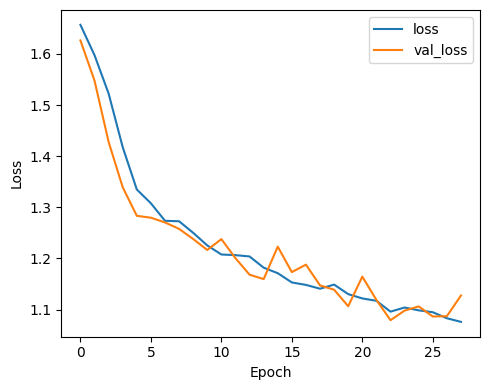

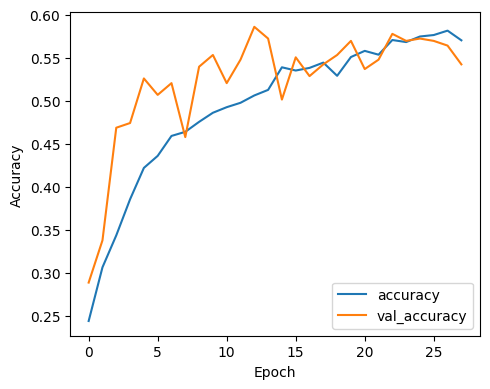

In [18]:
def preprocess_data_cnn(img, label):
  img = tf.cast(img, dtype=tf.float32) / 255.0
  img = tf.image.resize_with_pad(img, IMG_SIZE[0], IMG_SIZE[1])
  return img, label

train_cnn = data_train_raw.map(preprocess_data_cnn, num_parallel_calls=AUTOTUNE).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_cnn   = data_val_raw.map(preprocess_data_cnn, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_cnn  = data_test_raw.map(preprocess_data_cnn, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

data_augmentation = keras.Sequential([
  layers.RandomFlip('horizontal'),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
  layers.RandomTranslation(0.1, 0.1),
  layers.RandomContrast(0.1),
])

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)

x = layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-3))(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
  optimizer=keras.optimizers.Adam(),
  metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = keras.callbacks.ModelCheckpoint(
  'best_model_cnn.keras', monitor='val_loss', save_best_only=True
)

history = model.fit(
  train_cnn,
  epochs=EPOCHS,
  validation_data=val_cnn,
  callbacks=[early_stop, checkpoint],
  verbose=1
)

test_loss, test_acc = model.evaluate(test_cnn)
print("Accuracy on the test set:", test_acc)

plt.figure(figsize=(5,4))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

###Transfer learning (ResNet50)

*   ResNet50 (include_top=False, ImageNet weights) as a frozen feature extractor.
*   Head: Global Average Pooling -> Dense(1024) -> Dropout -> Dense(512,L2) -> Dropout -> softmax.
*   Optimizer: Adam
*   Loss: Sparse Categorical Crossentropy.
*   EarlyStopping + ModelCheckpoint to prevent overfitting.
*   Training with shuffled, batched, and prefetched datasets.

####Evaluation

*   Achieved strong performance within just a few epochs.
*   Validation accuracy quickly exceeded 90% and remained stable.
*   Final test accuracy: ~92%, clearly outperforming the custom CNN.
*   Training curves indicated fast convergence, benefiting from pretrained ImageNet features.

**Faster convergence and better validation performance than the custom CNN.**

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 755s 32s/step - accuracy: 0.5164 - loss: 1.6779 - val_accuracy: 0.8529 - val_loss: 0.4956
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 742s 32s/step - accuracy: 0.8441 - loss: 0.4883 - val_accuracy: 0.8529 - val_loss: 0.4781
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 747s 33s/step - accuracy: 0.8804 - loss: 0.3862 - val_accuracy: 0.9155 - val_loss: 0.3225
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 741s 32s/step - accuracy: 0.9099 - loss: 0.2996 - val_accuracy: 0.9101 - val_loss: 0.3199
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 749s 33s/step - accuracy: 0.9369 - loss: 0.2405 - val_accuracy: 0.9128 - val_loss: 0.3337
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 816s 33s/step - accuracy: 0.9519 - loss: 0.2146 - val_accuracy: 0.9019 - val_loss: 0.3530
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 738s 32s/step - accuracy: 0.9510 - loss: 0.2048 - val_accuracy: 0.9237 - val_loss: 0.3426
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 745s 32s/step -

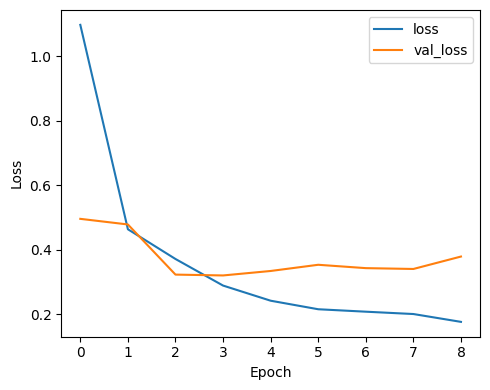

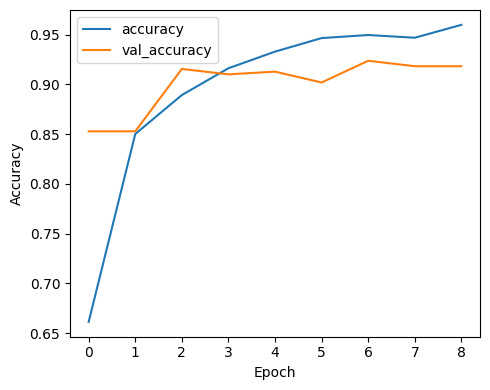

In [4]:
def preprocess_data(img, label):
  img = tf.cast(img, dtype=tf.float32)
  img = tf.image.resize_with_pad(img, IMG_SIZE[0], IMG_SIZE[1])
  return img, label

data_train = data_train_raw.map(preprocess_data, num_parallel_calls=AUTOTUNE).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
data_val   = data_val_raw.map(preprocess_data, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
data_test  = data_test_raw.map(preprocess_data, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

data_augmentation = keras.Sequential([
  layers.RandomFlip('horizontal'),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

inputs = keras.Input(shape=(None, None, 3))

x = data_augmentation(inputs)
x = keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input)(x)
base = ResNet50(include_top=False, weights='imagenet')
base.trainable = False
x = base(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
  optimizer=keras.optimizers.Adam(learning_rate=0.001),
  metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_model.keras', monitor='val_loss', save_best_only=True
)

history = model.fit(
  data_train,
  epochs=EPOCHS,
  validation_data=data_val,
  callbacks=[early_stop, checkpoint],
  verbose=1
)

test_loss, test_acc = model.evaluate(data_test)
print("Accuracy on the test set:", test_acc)

plt.figure(figsize=(5,4))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

###Deployment with Gradio

*   Simple upload -> predict flow
*   Returns the predicted class and confidence.
*   The UI clearly lists the five supported classes and scope/limitations.

In [ ]:
import gradio as gr
import numpy as np
from tensorflow import keras
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image


IMG_SIZE = (224, 224)
CLASS_NAMES = ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

model = keras.models.load_model(
  'best_model.keras',
  compile=False,
  custom_objects={'preprocess_input': preprocess_input}
)

def preprocess(img_np: np.ndarray) -> np.ndarray:
  if img_np.ndim == 2:
    img_np = np.stack([img_np]*3, axis=-1)
  if img_np.shape[-1] == 4:
    img_np = img_np[..., :3]
  pil = Image.fromarray(img_np.astype('uint8')).resize(IMG_SIZE[::-1], Image.BILINEAR)
  x = np.array(pil).astype('float32')
  x = preprocess_input(x)
  return x

def predict_fn(img):
  if img is None:
    return 'Upload file'
  x = preprocess(np.array(img))
  probs = model.predict(x[np.newaxis, ...], verbose=0)[0]
  idx = int(np.argmax(probs))
  return f'{CLASS_NAMES[idx]} ({probs[idx]:.3f})'

demo = gr.Interface(
  fn=predict_fn,
  inputs=gr.Image(type='numpy', label='Upload a photo of a flower'),
  outputs=gr.Textbox(label='Prediction'),
  title='Flowers Classifier',
  description=f"This model recognizes only: {', '.join(CLASS_NAMES)}"
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://805227bd64ff5391de.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://805227bd64ff5391de.gradio.live
